Loaded: results/value_only/0/training_logs.csv
Loaded: results/value_only/1/training_logs.csv
Loaded: results/value_only/2/training_logs.csv
Loaded: results/value_only/3/training_logs.csv
Loaded: results/value_only/4/training_logs.csv
Loaded: results/value_only/5/training_logs.csv
Loaded: results/value_only/6/training_logs.csv
Loaded: results/value_only/7/training_logs.csv
Loaded: results/value_only/8/training_logs.csv
Loaded: results/value_only/9/training_logs.csv
Loaded: results/value_only/10/training_logs.csv
Loaded: results/both/0/training_logs.csv
Loaded: results/both/1/training_logs.csv
Loaded: results/both/2/training_logs.csv
Loaded: results/both/3/training_logs.csv
Loaded: results/both/4/training_logs.csv
Loaded: results/both/5/training_logs.csv
Loaded: results/both/6/training_logs.csv
Loaded: results/both/7/training_logs.csv
Loaded: results/both/8/training_logs.csv
Loaded: results/both/9/training_logs.csv
Loaded: results/both/10/training_logs.csv
Loaded: results/obs_only/0/tra

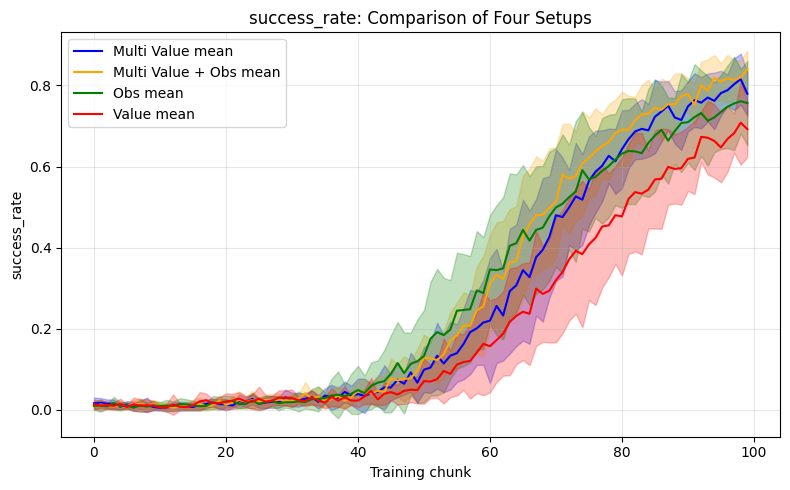

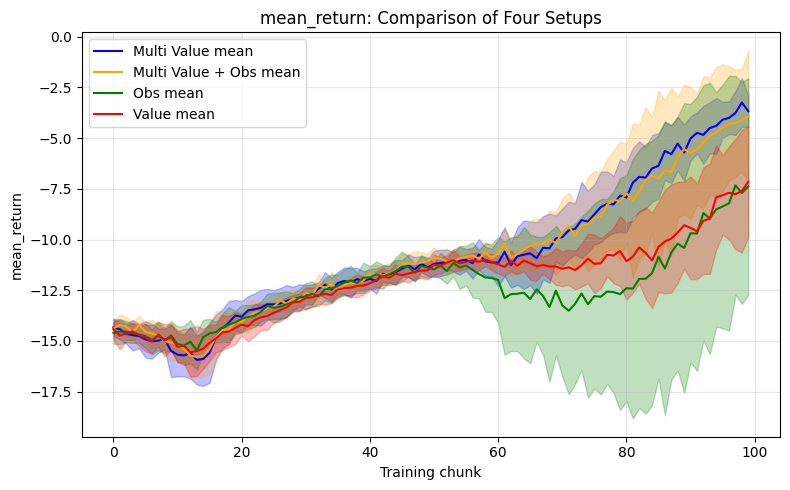

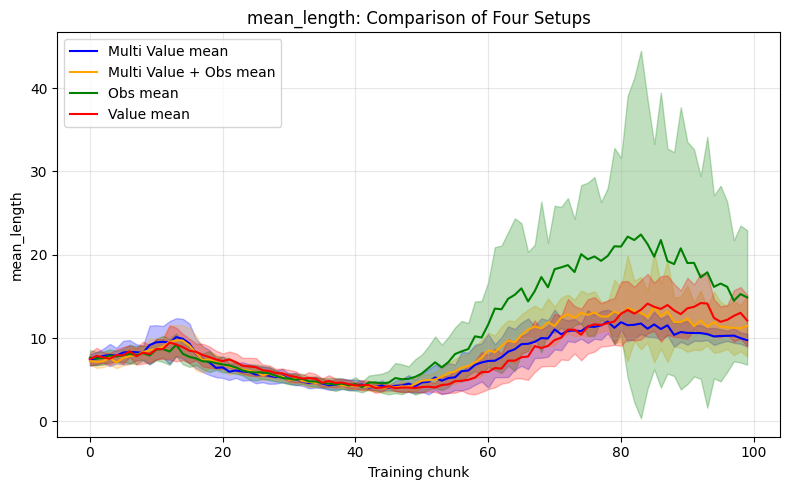

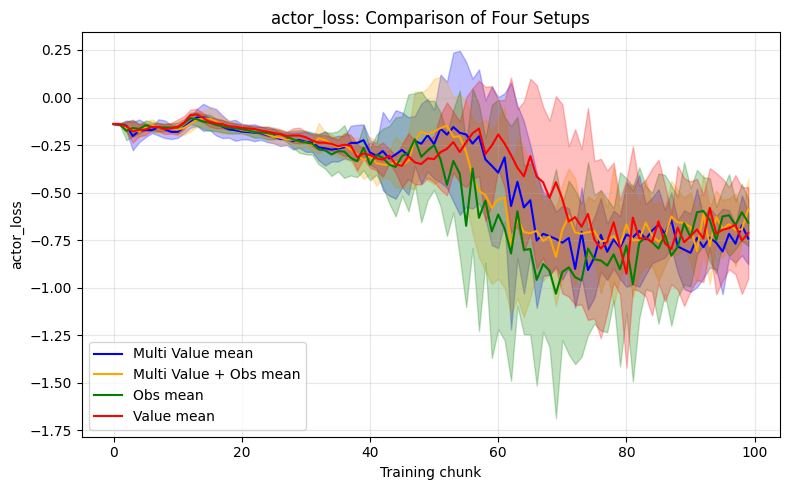

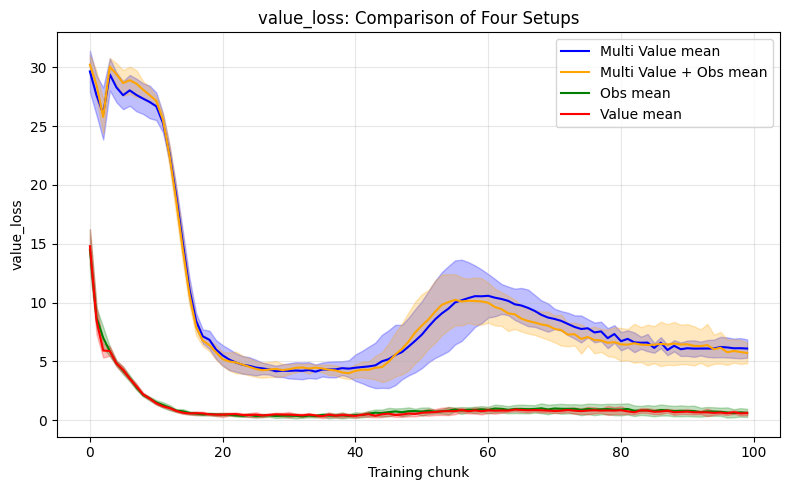

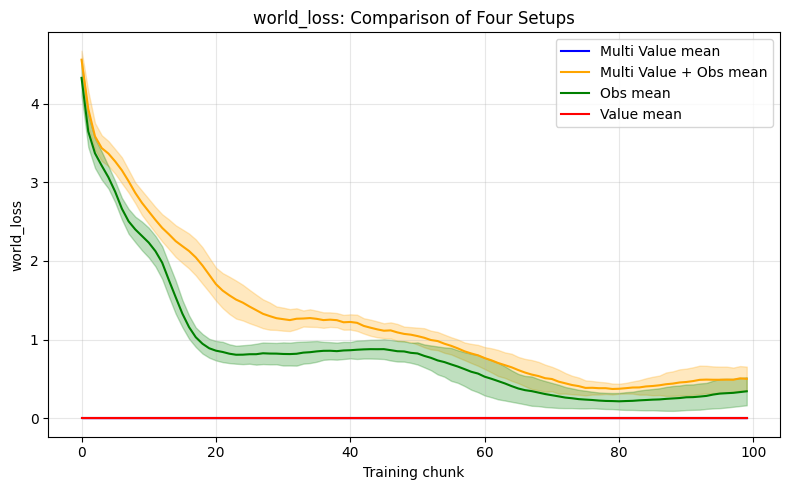

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# CONFIGURATION
# -------------------------------------------------------------------
EXPERIMENTS = [
    ("results/value_only", "Multi Value"),
    ("results/both", "Multi Value + Obs"),
    ("results/obs_only", "Obs"),
    ("results/single_value", "Value"),
]

CSV_NAME = "training_logs.csv"

METRICS = [
    "success_rate", "mean_return", "mean_length",
    "actor_loss", "value_loss", "world_loss"
]

COLORS = ["blue", "orange", "green", "red"]  # one for each experiment


# -------------------------------------------------------------------
# HELPER: Load all replicates from a single experiment folder
# -------------------------------------------------------------------
def load_experiment(base_dir):
    replicate_dfs = []

    folders = [f for f in os.listdir(base_dir) if f.isdigit()]
    folders = sorted(folders, key=lambda x: int(x))

    for folder in folders:
        csv_path = os.path.join(base_dir, folder, CSV_NAME)
        if os.path.isfile(csv_path):
            df = pd.read_csv(csv_path)
            df["chunk"] = np.arange(len(df))
            df["replicate"] = int(folder)
            replicate_dfs.append(df)
            print(f"Loaded: {csv_path}")

    if len(replicate_dfs) == 0:
        raise RuntimeError(f"No CSV logs found in {base_dir}")

    return pd.concat(replicate_dfs, ignore_index=True)


# -------------------------------------------------------------------
# LOAD AND PROCESS ALL FOUR EXPERIMENTS
# -------------------------------------------------------------------
experiment_stats = []  # list of (name, mean_df, std_df)

for (path, name) in EXPERIMENTS:
    data = load_experiment(path)
    mean_df = data.groupby("chunk")[METRICS].mean()
    std_df = data.groupby("chunk")[METRICS].std()
    experiment_stats.append((name, mean_df, std_df))


# -------------------------------------------------------------------
# PLOTTING — all experiments on the same axes
# -------------------------------------------------------------------
def plot_metric(metric):
    plt.figure(figsize=(8, 5))

    for (idx, (name, mean_df, std_df)) in enumerate(experiment_stats):
        color = COLORS[idx]

        # Plot mean line
        plt.plot(
            mean_df.index,
            mean_df[metric],
            label=f"{name} mean",
            color=color
        )

        # Plot shaded std band
        plt.fill_between(
            mean_df.index,
            mean_df[metric] - std_df[metric],
            mean_df[metric] + std_df[metric],
            alpha=0.25,
            color=color
        )

    plt.xlabel("Training chunk")
    plt.ylabel(metric)
    plt.title(f"{metric}: Comparison of Four Setups")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# -------------------------------------------------------------------
# PLOT ALL METRICS
# -------------------------------------------------------------------
for metric in METRICS:
    plot_metric(metric)
